<a href="https://colab.research.google.com/github/suyon0416/26-2_ESAA_YB/blob/main/YB_0918(2)_exercises_scores_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scores

### Introduction:

This time you will create the data.

***Exercise based on [Chris Albon](http://chrisalbon.com/) work, the credits belong to him.***

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np

### Step 2. Create the DataFrame that should look like the one below.
*참고*

```
raw_data = {'first_name': ['Jason', 'Molly', 'Tina', 'Jake', 'Amy'],
            'last_name': ['Miller', 'Jacobson', 'Ali', 'Milner', 'Cooze'],
            'female': [0, 1, 1, 0, 1],
            'age': [42, 52, 36, 24, 73],
            'preTestScore': [4, 24, 31, 2, 3],
            'postTestScore': [25, 94, 57, 62, 70]}
```

In [3]:
raw_data = {'first_name': ['Jason', 'Molly', 'Tina', 'Jake', 'Amy'],
            'last_name': ['Miller', 'Jacobson', 'Ali', 'Milner', 'Cooze'],
            'female': [0, 1, 1, 0, 1],
            'age': [42, 52, 36, 24, 73],
            'preTestScore': [4, 24, 31, 2, 3],
            'postTestScore': [25, 94, 57, 62, 70]}

df=pd.DataFrame(raw_data)
df

,first_name,last_name,female,age,preTestScore,postTestScore
0,Jason,Miller,0,42,4,25
1,Molly,Jacobson,1,52,24,94
2,Tina,Ali,1,36,31,57
3,Jake,Milner,0,24,2,62
4,Amy,Cooze,1,73,3,70


### Step 3. Create a Scatterplot of preTestScore and postTestScore, with the size of each point determined by age
#### Hint: Don't forget to place the labels

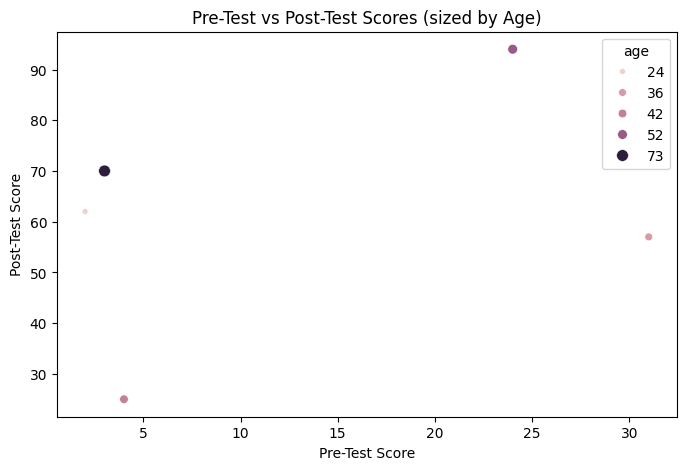

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# seaborn의 scatterplot을 이용해 크기(size)를 age로 지정
sns.scatterplot(x='preTestScore',y='postTestScore',size='age',data=df,hue='age')

plt.title('Pre-Test vs Post-Test Scores (sized by Age)')
plt.xlabel('Pre-Test Score')
plt.ylabel('Post-Test Score')
plt.show()

### Step 4. Create a Scatterplot of preTestScore and postTestScore.
### This time the size should be 4.5 times the postTestScore and the color determined by sex

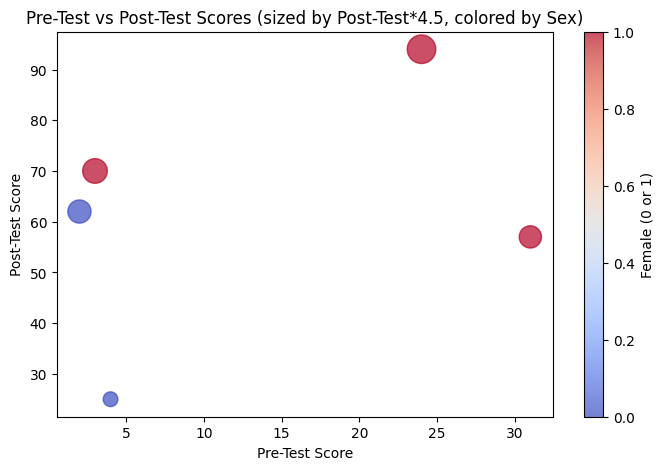

In [9]:
plt.figure(figsize=(8, 5))

# matplotlib의 scatter를 이용하면 점 크기(s)를 직접 수식으로 지정하기 편리합니다.
plt.scatter(
    x=df['preTestScore'],
    y=df['postTestScore'],
    s=df['postTestScore'] * 4.5,  # 크기를 postTestScore의 4.5배로 설정
    c=df['female'],  # 색상을 female 컬럼 값으로 지정
    cmap='coolwarm',  # 색상 팔레트
    alpha=0.7)

plt.title('Pre-Test vs Post-Test Scores (sized by Post-Test*4.5, colored by Sex)')
plt.xlabel('Pre-Test Score')
plt.ylabel('Post-Test Score')
plt.colorbar(label='Female (0 or 1)')  # 색상 범례(컬러바) 표시
plt.show()

### BONUS: Create your own question and answer it.

Q. 학생들이 시험을 치르기 전(Pre)과 후(Post)의 점수를 비교하여 성취도를 분석하시오.

--- 성별 평균 점수 비교 ---
        preTestScore  postTestScore  score_diff
female                                         
0           3.000000      43.500000   40.500000
1          19.333333      73.666667   54.333333


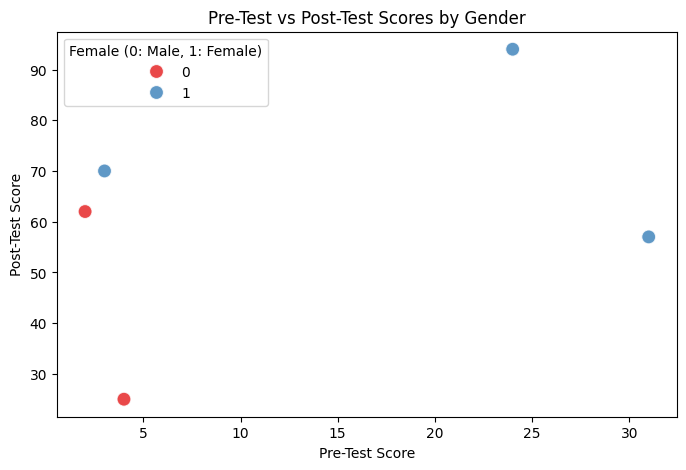

In [10]:
# 1. 전처리: 사후 점수에서 사전 점수를 뺀 '점수 향상폭(score_diff)' 파생 변수 생성
df['score_diff'] = df['postTestScore'] - df['preTestScore']

# 2. 그룹화: 성별(female)에 따른 사전/사후 테스트 평균 점수 비교
gender_grouped = df.groupby('female')[['preTestScore', 'postTestScore', 'score_diff']].mean()
print("--- 성별 평균 점수 비교 ---")
print(gender_grouped)

# 3. 시각화: Pre vs Post 산점도 (성별에 따른 색상 구분)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='preTestScore',
    y='postTestScore',
    hue='female',         # 성별에 따라 색상 다르게 지정
    data=df,
    palette='Set1',
    s=100,                # 점 크기
    alpha=0.8
)

# 4. 그래프 레이블 및 제목 설정
plt.title('Pre-Test vs Post-Test Scores by Gender')
plt.xlabel('Pre-Test Score')
plt.ylabel('Post-Test Score')
plt.legend(title='Female (0: Male, 1: Female)')

# 5. 그래프 출력
plt.show()